(sec:SetupLinearRegressionOutliers)=
# Setup: linear regression with data outliers


We will use as our canonical analysis a set of data that mostly lies on a straight line but has several points that are far away. 
(This example and subsequent discussion was adapted from the blog post [Frequentism and Bayesianism II: When Results Differ](http://jakevdp.github.io/blog/2014/06/06/frequentism-and-bayesianism-2-when-results-differ/).)

## Sample dataset

Consider the following plotted dataset, relating the observed variables $x$ and $y$, with errors on $y$. (You will have the opportunity to explore different datasets and errors in {ref}`demo:dealing-with-outliers`.)

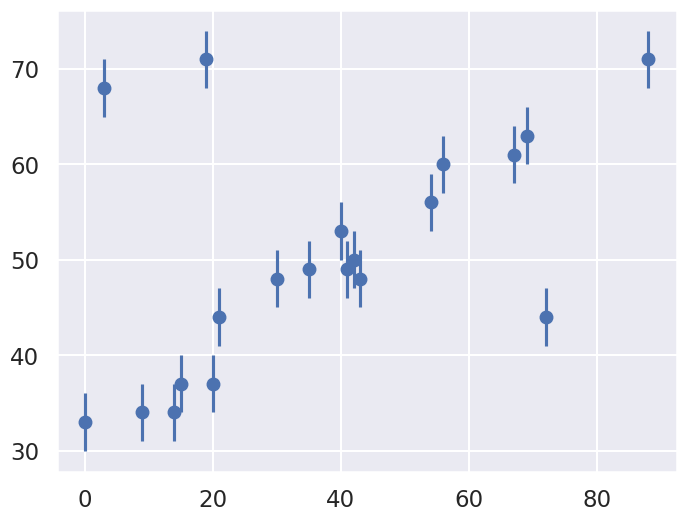

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(); sns.set_context("talk")

import emcee
import corner

# note that x and y will be used as global arrays
x = np.array([ 0,  3,  9, 14, 15, 19, 20, 21, 30, 35,
              40, 41, 42, 43, 54, 56, 67, 69, 72, 88])
y = np.array([33, 68, 34, 34, 37, 71, 37, 44, 48, 49,
              53, 49, 50, 48, 56, 60, 61, 63, 44, 71])
sig0 = 3.
e = sig0*np.ones_like(y)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
ax.errorbar(x, y, e, fmt='o');

Our task is to find a line of best-fit to the data. It's clear upon visual inspection that there are some outliers among these points, but let's start with a simple non-robust maximum likelihood approach. 

## The Model

Here we review the procedure for fitting a straight line to data, emphasizing the role of the statistical model.  We take as our model ("$M$" here stands for "Model"; elsewhere we use "th" for theory), 

$$
y_M(x; \boldsymbol{\theta}) = \theta_0 + \theta_1 x ,
$$

where our parameter vector will be 

$$
\boldsymbol{\theta} = [\theta_0, \theta_1].
$$

But this is only half the picture: what we mean by a "model" in a Bayesian sense is not only this expected value $y_M(x;\boldsymbol{\theta})$, but a **probability distribution** for our data.
That is, we need an expression to compute the likelihood $p(D\mid\boldsymbol{\theta},I)$ for our data as a function of the parameters $\boldsymbol{\theta}$.

The Bayesian statistical model we employ is that the distribution of data $D$ is the sum of the distributions for the model, the model discrepancy, and the observation error: 

$$
   D = M + \delta M + \delta D .   
$$

The model discrepancy term $\delta M$ is in general important to consider, but we will neglect it here (e.g., assuming it is much smaller than $\delta D$). 

To establish $\delta D$, we note that here we are given data with simple error bars, which imply that the probability for any *single* data point is a normal distribution about the true value. In this example, the errors are specified by a single parameter $\sigma_0$ (again, we neglect $\delta M$). That is, $y_i = D_i$ is given by

$$
y_i \sim \mathcal{N}(y_M(x_i;\boldsymbol{\theta}), \sigma_0^2)
$$

or, in functional form,

$$
p(y_i\mid x_i,\boldsymbol{\theta}) = \frac{1}{\sqrt{2\pi\sigma_0^2}} \exp\left(\frac{-\left[y_i - y_M(x_i;\boldsymbol{\theta})\right]^2}{2\sigma_0^2}\right)
$$

The (known) variance of the measurement errors, $\sigma_0$, is indicated in the figure below by the error bars.

Assuming all the points are independent, we can find the full likelihood by multiplying the individual likelihoods together:

$$
p(D\mid\boldsymbol{\theta}, I) = \prod_{i=1}^N p(y_i\mid x_i,\boldsymbol{\theta}, I) .
$$

For convenience (and also for numerical accuracy) this is often expressed in terms of the log-likelihood:

\begin{align}
\log p(D\mid\boldsymbol{\theta}, I) &= -\frac{1}{2}\sum_{i=1}^N\left(\log(2\pi\sigma_0^2) + \frac{\left[ y_i - y_M(x_i;\theta)\right]^2}{\sigma_0^2}\right) \\
&= \text{constant} - \sum_{i=1}^N \frac{\left[ y_i - y_M(x_i;\boldsymbol{\theta})\right]^2}{2 \sigma_0^2} .
\end{align}

We often define the *residuals* (the notation $z_i$ is also common)

$$
R_i = \left[ y_i - y_M(x_i;\boldsymbol{\boldsymbol{\theta}}) \right]/\sigma_0,
$$

so that the relevant chi-square sum is $\chi^2 =  \sum_{i=1}^N R_i^2$.


The summation term that appears in this log-likelihood is often known as the *loss function*.  This particular loss function is known as a *squared loss* or *chi-squared*; but as you can see it can be derived from the Gaussian log likelihood.